<a href="https://colab.research.google.com/github/haskinse/bee2041_empirical_project/blob/main/source_code/04_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from google.colab import drive # connect to google drive
drive.mount("/content/drive")

project_path = "/content/drive/MyDrive/bee2041_empirical_project" # define project path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
era_colours = { # a dictionary to match era to consistant colours
  "Taylor Swift": "#a4caa5", # green / teal
  "Fearless": "#f0c080", # yellow / gold
  "Speak Now": "#c7a8ca", # purple
  "Red": "#7a2e3a", # red
  "1989": "#b5e5f9", # light blue
  "Reputation": "#000000", # black
  "Lover": "#f6b0cc", # pink
  "Folklore": "#cdc9c0", # grey
  "Evermore": "#c5ac90", # brown
  "Midnights": "#1b4b7d", # navy
  "TTPD": "#e3dcdc", # white
  "The Life of a Showgirl": "#e15921" # orange
}

In [31]:
import matplotlib.pyplot as plt # library for data visualisation
import pandas as pd # library for data manipulation and tables
import seaborn as sns # used for statistical data visualisation
import sqlite3 # ibrary used to create and interact with SQLite databases

In [32]:
def plot_chart_performance(chart_peak, country, figure_name): # plot album chart performance for a given country

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve album names and chart peak metric
  chart_performance = pd.read_sql(f"""
  SELECT album_id, album_name, {chart_peak} AS chart_peak
  FROM albums
  """, conn)

  # exclude Taylor’s Version albums to avoid doubling of eras
  chart_performance = chart_performance[~chart_performance["album_name"].str.contains("Taylor's Version", regex=False)]

  # replace long names with abbreviations for easier visualisation
  chart_performance["album_name"] = chart_performance["album_name"].replace({"The Tortured Poets Department": "TTPD"})
  chart_performance["album_name"] = chart_performance["album_name"].replace({"The Life of a Showgirl": "Life of a Showgirl"})

  base_colours = chart_performance["album_name"].astype(str).map(era_colours).fillna("#cccccc") # assign consistent colours to each era

  sns.reset_defaults() # ensures that style is set to default

  plt.figure(figsize = (8, 6)) # set figure size

  plt.plot(chart_performance["album_name"], chart_performance["chart_peak"], color = "grey", linestyle = "--") # plot a trend line across eras

  plt.scatter(chart_performance["album_name"], chart_performance["chart_peak"], color = base_colours) # add scatter points coloured by era

  plt.xticks(rotation = 45, ha = "right") # rotate labels for readability

  # label the axes and title
  plt.xlabel("Era")
  plt.ylabel("Chart Peak")
  plt.title(f"{country} Chart Peaks by Era")

  lowest_peak = chart_performance["chart_peak"].max() # find the worst chart position

  if lowest_peak < 10:
    offset = 0.1 # use small label offset when values are across a small scale

  else:
    offset = 2 # use larger offset when values are more spread out

  # annotate each point with its chart peak value
  for i, row in chart_performance.iterrows():
    plt.text(row["album_name"], row["chart_peak"] - offset, str(row["chart_peak"]), fontsize = 9, ha = "center")

  # remove unnecessary borders for cleaner visualisation
  plt.gca().spines["top"].set_visible(False)
  plt.gca().spines["right"].set_visible(False)

  plt.gca().invert_yaxis() # swap the axis so rank 1 is at the top

  plt.savefig(f"{project_path}/output/figures/chart_performance/{figure_name}.png", dpi=300, bbox_inches="tight") # saves figure to drive

  plt.tight_layout()
  plt.show() # show the final chart

  conn.close() # close database connection

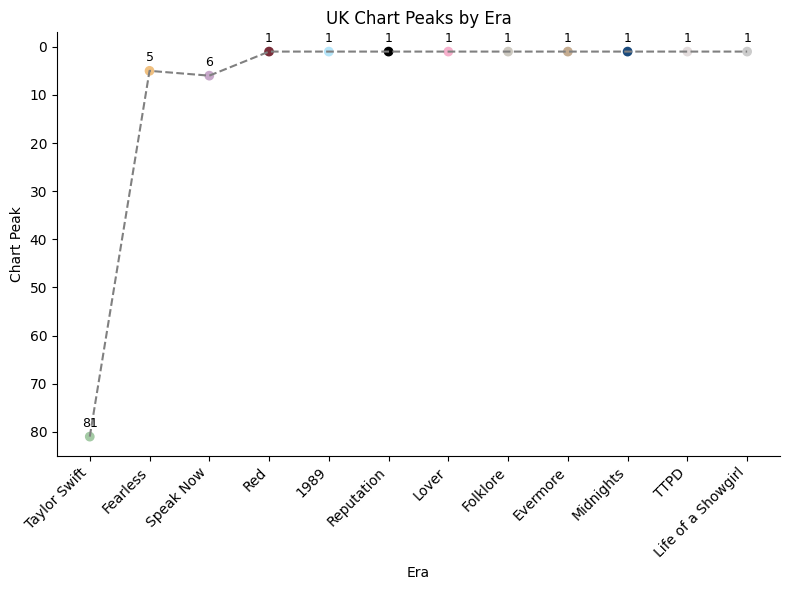

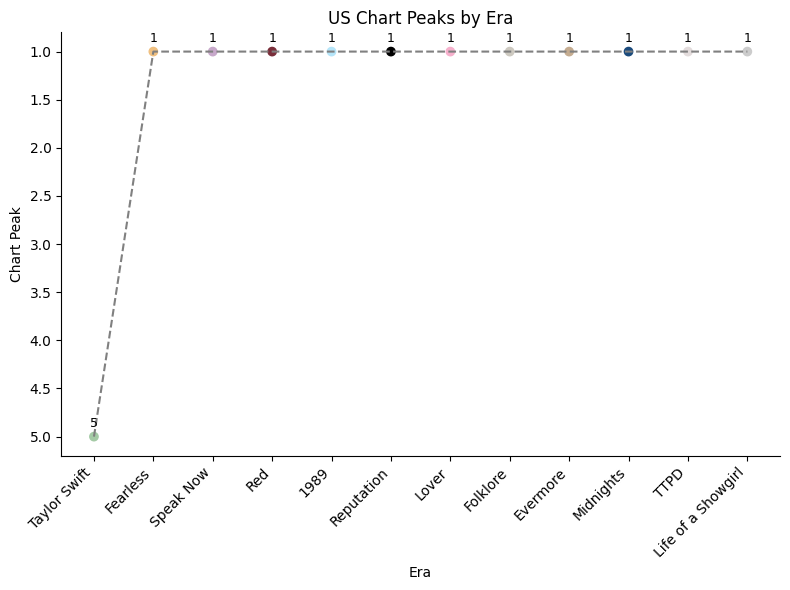

In [33]:
plot_chart_performance("uk_peak", "UK", "uk_chart_performance") # plot the chart performance of Taylor Swift eras in the UK

plot_chart_performance("us_peak", "US", "us_chart_performance") # plot the chart performance of Taylor Swift eras in the US

In [34]:
import matplotlib.colors as mcolors # for manipulating colours

In [35]:
def lighten_colour(colour, amount): # function to lighten colours
  c = mcolors.to_rgb(colour) # converts colour to rgb
  return tuple(1 - (1 - x) * (1 - amount) for x in c) # shifts it towards white

In [36]:
# list of eras in order
era_order = ["Taylor Swift", "Fearless", "Speak Now", "Red", "1989", "Reputation", "Lover", "Folklore", "Evermore", "Midnights", "TTPD", "The Life of a Showgirl"]

In [39]:
def plot_commercial_success(metric_a, metric_b, metric_name, figure_name): # analyse and visualise era success using metrics

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve album data and compute combined success metric
  popularity_by_metric = pd.read_sql(f"""
  SELECT album_id, album_name, {metric_a} + {metric_b} AS total_metric
  FROM albums
  """, conn)

  popularity_by_metric["total_metric"] = popularity_by_metric["total_metric"] / 1000000 # scale values to millions for clearer visualisation

  # group Taylor’s Version albums with their original era
  popularity_by_metric["era"] = popularity_by_metric["album_name"].str.replace(r" \(Taylor's Version\)", "", regex = True)

  # create indicator for Taylor’s Version vs original releases
  popularity_by_metric["is_tv"] = popularity_by_metric["album_name"].str.contains("Taylor's Version", regex = False)

  popularity_by_metric["era"] = popularity_by_metric["era"].replace({"The Tortured Poets Department": "TTPD"}) # replace Tortured Poets with TTPD for readability

  base_colours = popularity_by_metric["era"].astype(str).map(era_colours).fillna("#cccccc") # assign consistent colours to each era

  tv_colours = [lighten_colour(c, 0.5) for c in base_colours] # create lighter shades to show Taylor’s Version albums

  sns.reset_defaults() # ensures that the sns style starts at default
  sns.set_style("whitegrid") # adds a grid in the background of the figure

  plt.figure(figsize=(6, 6)) # plot the pie chart

  # visualise proportion of total success contributed by each era
  plt.pie(popularity_by_metric["total_metric"], labels = popularity_by_metric["era"], colors = base_colours, startangle = 90, wedgeprops = {"edgecolor": "white"})

  plt.title(f"Share of Total {metric_name} by Era") # label the title

  plt.savefig(f"{project_path}/output/figures/commercial_success/{figure_name}_pie.png", dpi=300, bbox_inches="tight") # saves figure to drive

  plt.tight_layout()
  plt.show() # show the graph

  # reshape data to separate original and Taylor’s Version contributions per era
  popularity_by_metric = (popularity_by_metric.pivot_table(index = "era", columns = "is_tv", values = "total_metric", aggfunc = "sum", fill_value = 0).rename(columns = {False: "original", True: "tv"}).reset_index())

  # enforce chronological ordering of eras
  popularity_by_metric["era"] = pd.Categorical(popularity_by_metric["era"], categories = era_order, ordered = True)

  popularity_by_metric = popularity_by_metric.sort_values("era") # sort data according to defined era order

  plt.figure(figsize = (8, 6)) # create a stacked bar chart

  # plot original album performance
  plt.bar(popularity_by_metric["era"], popularity_by_metric["original"], label = "Original", color = base_colours)

  # add stacked Taylor’s Version contributions
  plt.bar(popularity_by_metric["era"], popularity_by_metric["tv"], bottom = popularity_by_metric["original"], label = "Taylor's Version", color = tv_colours)

  plt.xticks(rotation = 45, ha = "right") # rotate labels for readability

  # label chart axes and title
  plt.xlabel("Era")
  plt.ylabel(f"Total {metric_name} (Millions)")
  plt.title(f"Most Successful Taylor Swift Eras (by US & UK {metric_name})")

  plt.legend() # display legend for original vs Taylor’s Version

  # remove unnecessary borders
  plt.gca().spines["top"].set_visible(False)
  plt.gca().spines["right"].set_visible(False)

  plt.savefig(f"{project_path}/output/figures/commercial_success/{figure_name}_bar.png", dpi=300, bbox_inches="tight") # saves figure to drive

  plt.tight_layout()
  plt.show() # display final chart

  conn.close() # close database connection

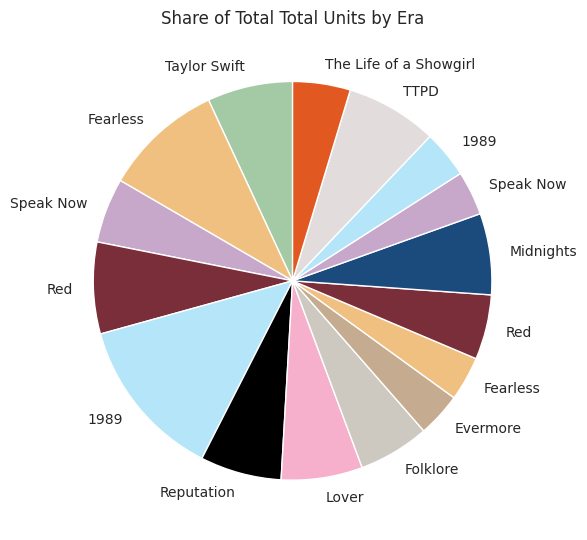

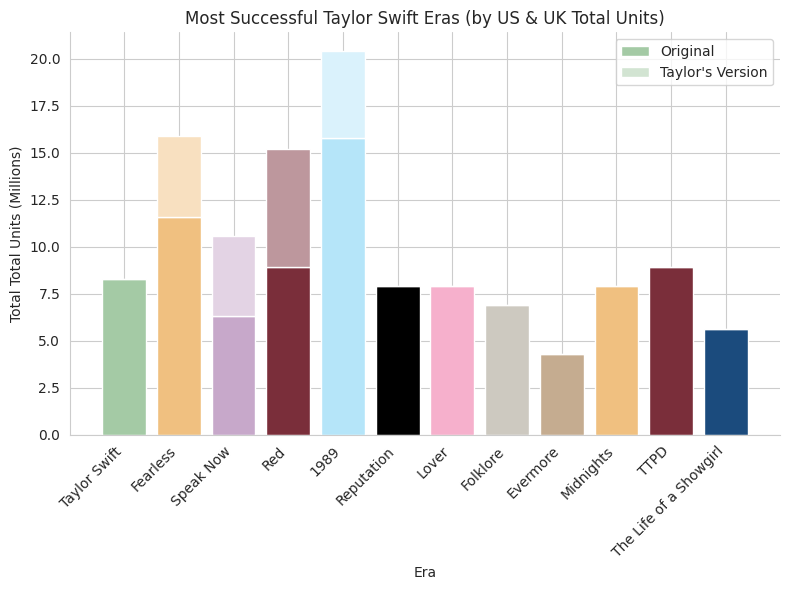

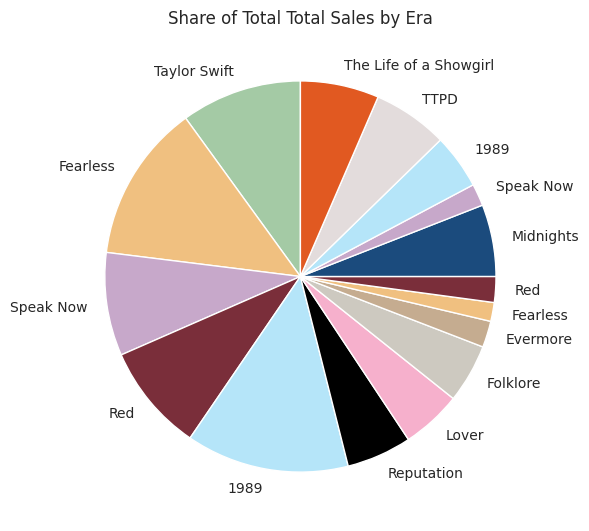

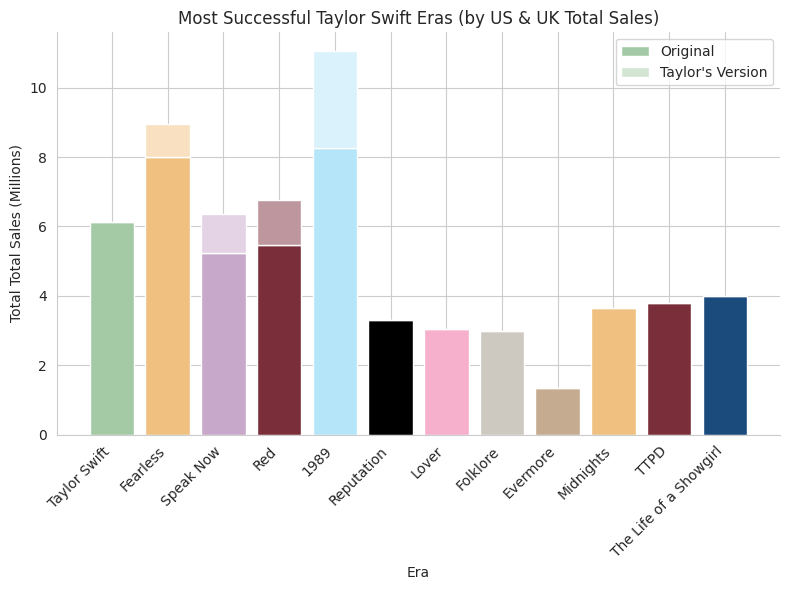

In [40]:
plot_commercial_success("riaa_units", "bpi_units", "Total Units", "total_units") # plot charts showing certification units of albums
plot_commercial_success("us_sales", "uk_sales", "Total Sales", "total_sales") # plot charts showing sales of albums